# Sesión 03 — Regresión lineal simple y múltiple

**Bloque:** 2 · Regresión

## Objetivos

Al terminar esta sesión deberías ser capaz de:

- Decidir si un problema se ataca con una sola variable o con varias, y justificar la decisión con datos y no con intuición.
- Preparar un dataset con variables categóricas para un modelo lineal, eligiendo la codificación y explicando qué hace `drop_first`.
- Entrenar y evaluar una `LinearRegression` sobre datos que el modelo no ha visto, leyendo R², MAE y RMSE juntos y no por separado.
- Traducir los coeficientes del modelo a frases que un cliente entienda ("cada año de edad suma X € a la prima").
- Comparar dos modelos con distinto número de variables y defender cuál de los dos entregarías.

## Qué necesitas de antes

- **S02 — Python aplicado al análisis de datos**: pandas, lectura de ficheros desde URL, gráficos con seaborn y matplotlib.
- Selección de columnas en un DataFrame y lectura de un `describe()`.


## 1. ¿Qué es la Regresión?

En Machine Learning, usamos la regresión cuando queremos predecir un valor **numérico continuo**. Por ejemplo:
- Predecir el precio de una casa.
- Estimar la temperatura de mañana.
- Predecir el coste del seguro médico de una persona (¡nuestro caso de hoy!).

La **Regresión Lineal** es el modelo más sencillo para esta tarea. Asume que existe una relación lineal entre las variables de entrada (X, también llamadas *features* o predictoras) y la variable de salida (y, también llamada *target* o variable dependiente). La fórmula que busca aprender es la de una línea (o un hiperplano en más dimensiones):

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$

- $\beta_0$ es el **intercepto** (el valor de $y$ cuando todas las $x$ son cero).
- $\beta_1, \beta_2, ...$ son los **coeficientes** de cada variable. Nos dicen cuánto cambia $y$ por cada unidad que aumenta la $x$ correspondiente, manteniendo las demás constantes.

- **Regresión Lineal Simple:** Solo tenemos una variable de entrada ($x_1$).
- **Regresión Lineal Múltiple:** Usamos varias variables de entrada ($x_1, x_2, ..., x_n$).

**Qué problema resuelve:** predecir un número continuo a partir de otras variables, cuando además interesa poder *explicar* la predicción.

**Cuándo elegirla:** como primer modelo casi siempre. Es rápida, no tiene hiperparámetros que ajustar y sus coeficientes se leen directamente en unidades del negocio. Es la referencia contra la que se compara todo lo demás: si un modelo más complejo no la supera, no compensa.

**Cuándo NO:** cuando la relación es claramente curva o hay interacciones fuertes entre variables (un efecto que solo aparece al combinar dos), o cuando hay muchas más columnas que filas.

**Qué asume:** que la relación entre cada variable y el objetivo es lineal, que los errores no dependen del tamaño de la predicción y que las variables predictoras no son redundantes entre sí. Los tres supuestos se incumplen a menudo, y parte del trabajo de hoy es detectar dónde.


In [23]:
# Importamos las librerías fundamentales que usaremos en la sesión
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos seaborn para que los gráficos se vean un poco más atractivos
sns.set_theme(style="whitegrid")

## 2. Carga y Exploración de Datos (EDA)

Vamos a trabajar con el dataset "Medical Cost Personal Datasets", que se encuentra en Kaggle. Contiene información anónima sobre los asegurados de una compañía y su objetivo es predecir los `charges` (costes médicos facturados).

Las columnas son:
- `age`: edad del beneficiario.
- `sex`: sexo del beneficiario.
- `bmi`: índice de masa corporal.
- `children`: número de hijos cubiertos por el seguro.
- `smoker`: si la persona es fumadora o no.
- `region`: la región de residencia en EEUU.
- `charges`: los costes médicos individuales facturados por el seguro (nuestra **variable objetivo**).

In [24]:
# Cargamos los datos directamente desde una URL para que sea reproducible
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

In [25]:
# Damos un primer vistazo a los datos
print("Primeras 5 filas del dataset:")
print(df.head())

In [26]:
print("\nInformación general y tipos de datos:")
df.info()

In [27]:
print("\nEstadísticas descriptivas de las columnas numéricas:")
print(df.describe())

### Análisis Visual

Antes de construir un modelo, un buen analista siempre "mira" sus datos. Las visualizaciones nos dan una intuición clave.

In [28]:
# 1. ¿Cómo se distribuyen los costes (nuestra variable objetivo)?
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribución de los Costes del Seguro (charges)', fontsize=16)
plt.xlabel('Costes ($)')
plt.ylabel('Frecuencia')
plt.show()

# Reflexión: Vemos que la mayoría de la gente tiene costes bajos, con una larga cola hacia la derecha (right-skewed).
# Esto nos dice que hay un grupo de personas con costes muy, muy altos. ¿Quiénes serán?

## 3. Preparación de Datos

Los modelos de machine learning no entienden de texto ('male', 'female', 'yes', 'no'). Necesitamos convertir las variables categóricas en números. La técnica estándar es **One-Hot Encoding**. `pandas` nos lo pone muy fácil con la función `get_dummies`.

In [29]:
# Convertimos las variables categóricas en numéricas
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# drop_first=True evita la multicolinealidad. Por ejemplo, si tenemos sex_male, no necesitamos
# una columna sex_female, porque si sex_male es 0, sabemos que es female.

print("Dataset después de One-Hot Encoding:")
print(df_encoded.head())

### Matriz de Correlación

Ahora que todo es numérico, podemos calcular la correlación entre todas las variables. Una matriz de correlación visualizada con un mapa de calor (heatmap) es una herramienta potentísima para intuir qué variables serán más importantes para predecir `charges`.

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de todas las variables', fontsize=16)
plt.show()

# Interpretación: Buscamos en la fila/columna 'charges' los colores más intensos (rojos o azules).
# 'smoker_yes' tiene una correlación muy alta (0.79), 'age' (0.30) y 'bmi' (0.20) también parecen relevantes.
# ¡Esto ya nos da pistas para nuestro modelo!

## 4. Modelo de Regresión Lineal Múltiple (Ejemplo Guiado)

Vamos a construir nuestro primer modelo para predecir `charges` usando todas las variables disponibles.

**Pasos clave:**
1.  **Separar X e y**: `X` contiene las variables predictoras, `y` contiene la variable objetivo.
2.  **Dividir en train/test**: Usamos una parte de los datos para entrenar el modelo (`train`) y una parte que el modelo no ha visto nunca para evaluarlo (`test`). Esto es CRUCIAL para saber si nuestro modelo generaliza bien.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Separar las variables predictoras (X) de la variable objetivo (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 2. Dividir los datos en entrenamiento y prueba
# Usamos un 80% para entrenar y un 20% para testear.
# random_state=42 asegura que la división sea siempre la misma, para que nuestros resultados sean reproducibles.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el modelo
# Creamos una instancia del modelo de Regresión Lineal
model = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

## 5. ¿Qué tan bueno es nuestro modelo? Evaluación

Entrenar un modelo es fácil. La parte difícil es saber si es bueno. Para ello, usamos los datos de `test` que habíamos guardado.

**Hacemos predicciones y las comparamos con la realidad.**

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hacemos predicciones sobre el conjunto de test (datos que el modelo no ha visto)
y_pred = model.predict(X_test)

# Visualicemos qué tan cerca están las predicciones de la realidad
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Costes Reales (y_test)")
plt.ylabel("Costes Predecibles (y_pred)")
plt.title("Costes Reales vs. Predicciones del Modelo", fontsize=16)
# Dibujamos una línea de 45 grados. Si las predicciones fueran perfectas, todos los puntos caerían sobre esta línea.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

### Métricas de Error

- **MAE (Error Absoluto Medio):** Nos dice, en promedio, cuántos dólares se equivoca nuestra predicción. Es fácil de interpretar.
- **RMSE (Raíz del Error Cuadrático Medio):** Similar al MAE, pero como eleva los errores al cuadrado, penaliza mucho más los errores grandes.
- **$R^2$ (R-cuadrado):** Nos dice qué porcentaje de la variación de los costes es explicado por el modelo. Va de 0 a 1 (o incluso negativo). Un valor más cercano a 1 es mejor.

In [33]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Error Absoluto Medio): ${mae:,.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): ${rmse:,.2f}")
print(f"R-cuadrado (R²): {r2:.2f}")

### Interpretación de Coeficientes
¿Qué ha aprendido el modelo? ¿Qué variables considera más importantes?

In [34]:
# Creamos un DataFrame para ver los coeficientes de forma ordenada
coeficientes = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
print("Intercepto del modelo (Beta_0):", model.intercept_)
print("\nCoeficientes de las variables:")
print(coeficientes)

# Interpretación: Por cada año que una persona envejece ('age'), el coste de su seguro aumenta en ~$256, si todo lo demás se mantiene constante.
# ¡Ser fumador ('smoker_yes') dispara los costes en casi $24,000!

---
## Ejercicio 1 — Regresión lineal simple

Ahora es tu turno. La intuición y la matriz de correlación nos dijeron que `bmi` (Índice de Masa Corporal) podría ser un predictor. Vamos a investigarlo por sí solo.

**Tareas:**
1.  **Define tus variables `X_simple` e `y_simple`**. `X_simple` debe ser únicamente la columna `bmi` del dataframe `df_encoded`. `y_simple` sigue siendo `charges`.
2.  **Divide los datos** en conjuntos de entrenamiento y prueba (`train_test_split`). Usa un `test_size=0.2` y `random_state=42`.
3.  **Crea y entrena un nuevo modelo** de `LinearRegression`.
4.  **Realiza predicciones** sobre el conjunto de prueba.
5.  **Calcula el R-cuadrado ($R^2$)** del modelo. ¿Qué tan bueno es comparado con el modelo múltiple que hicimos antes?
6.  **Visualiza el resultado**: Dibuja un `scatterplot` con los datos de prueba (`X_test_simple`, `y_test_simple`) y superpón la línea de regresión que ha aprendido tu modelo.

¡Modelo entrenado con éxito!
R-cuadrado (R²): 0.04


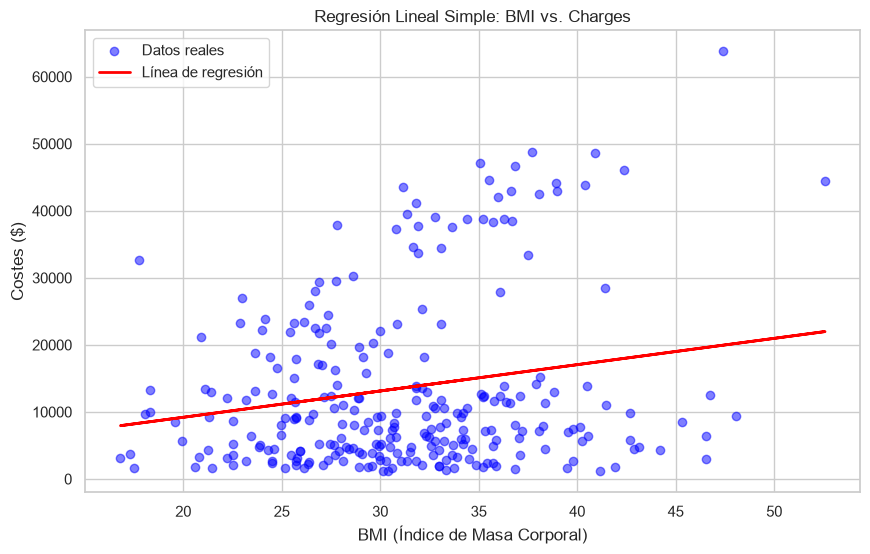

In [35]:
# TODO: completa esta celda
# sklearn espera que X tenga dos dimensiones: una sola columna no es df_encoded['bmi'].
# Para la recta te basta con dibujar las predicciones que ya has calculado sobre X_test_simple.

# 1. Define tus variables `X_simple` e `y_simple`**. `X_simple` debe ser únicamente la columna `bmi` del dataframe `df_encoded`. `y_simple` sigue siendo `charges`
x_simple = df_encoded[['bmi']]#nos pide el formato de tabla.
y_simple = df_encoded['charges']

# 2. Divide los datos en conjuntos de entrenamiento y prueba (`train_test_split`). Usa un `test_size=0.2` y `random_state=42`
# Usamos un 80% para entrenar y un 20% para testear. random_state=42 asegura que la división sea siempre la misma, para que nuestros resultados sean reproducibles.
X_train, X_test, y_train, y_test = train_test_split(x_simple, y_simple, test_size=0.2, random_state=42)

# 3. Crea y entrena un nuevo modelo** de `LinearRegression`.
modelBMI = LinearRegression() # Creamos una instancia del modelo de Regresión Lineal
modelBMI.fit(X_train, y_train) # Entrenamos el modelo con los datos de entrenamiento

print("¡Modelo entrenado con éxito!")

# 4. Realiza predicciones** sobre el conjunto de prueba.
y_pred = modelBMI.predict(X_test) # Hacemos predicciones sobre el conjunto de test (datos que el modelo no ha visto)
#cuanto mas alto es el resultado, es mejor. si tenemos tan poco resultados 0.4 algo asi es que se tiene que entrenar mas

# 5. Calcula el R-cuadrado ($R^2$)** del modelo. ¿Qué tan bueno es comparado con el modelo múltiple que hicimos antes?
r2 = r2_score(y_test, y_pred)
print(f"R-cuadrado (R²): {r2:.2f}")

# 6. Visualiza el resultado**: Dibuja un `scatterplot` con los datos de prueba (`X_test_simple`, `y_test_simple`) y superpón la línea de regresión que ha aprendido tu modelo.
plt.figure(figsize=(10, 6))                                                                          # Preparamos el lienzo en blanco de tamaño grande
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Datos reales')             # Pintamos los puntos azules de los clientes reales del examen
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de regresión')         # Dibujamos la línea roja con las predicciones que hace el modelo

plt.title('Regresión Lineal Simple: BMI vs. Charges')                                                 # Ponemos el título del gráfico
plt.xlabel('BMI (Índice de Masa Corporal)')                                                           # Nombre para el eje horizontal
plt.ylabel('Costes ($)')                                                                              # Nombre para el eje vertical
plt.legend()                                                                                          # Mostramos la leyenda con la explicación de los colores
plt.show()                                                                                            # Mostramos el gráfico final en pantalla

### Mis reflexiones

*(Escribe aquí tu respuesta antes de seguir)*

- Acabas de ver que `bmi` por sí solo explica muy poco del gasto. ¿Qué conclusión sacas: que la variable no sirve, o que el problema es otro? Argumenta cuál de las dos.
- En el gráfico hay puntos que quedan muy por encima de la recta. Sin mirar todavía el resto de columnas, ¿qué hipótesis te haces sobre esas personas y cómo la comprobarías?
- Si la aseguradora te pidiera hoy una estimación rápida del coste de un cliente nuevo y solo tuvieras este modelo, ¿la darías? ¿Con qué advertencia?


---
## Preguntas de recap – Regresión simple

1. ¿Qué mide el coeficiente de una regresión lineal simple?  
2. ¿Qué significa el intercepto (ordenada en el origen)?  
3. ¿Qué nos indica el R² de un modelo?  
4. Si al ajustar una regresión obtenemos un coeficiente negativo, ¿cómo lo interpretarías?

---


---
## Ejercicio 2 — Un modelo más simple

El modelo con todas las variables es mucho mejor que el que solo usa `bmi`. Pero en el mundo real, la simplicidad es una virtud. Un modelo con menos variables es más fácil de explicar y mantener.

**Tu misión:**
Construye y evalúa un modelo de regresión lineal múltiple usando **únicamente un subconjunto de variables** que, a tu juicio (y según el heatmap), son las más importantes: `age`, `bmi` y `smoker_yes`.

**Pasos:**
1.  Prepara tu `X_reducido` seleccionando solo esas tres columnas del dataframe `df_encoded`. La `y` no cambia.
2.  Divide los datos en entrenamiento y prueba (`random_state=42`).
3.  Entrena el modelo de regresión lineal.
4.  Realiza una **evaluación completa**: calcula el MAE, RMSE y $R^2$.
5.  Crea la **visualización** de predicciones vs. valores reales para este nuevo modelo.

**--- Preguntas para la Reflexión ---**


In [39]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


¡Modelo entrenado con éxito!
MAE (Error Absoluto Medio): $4,260.56
RMSE (Raíz del Error Cuadrático Medio): $5,874.76
R-cuadrado (R²): 0.78


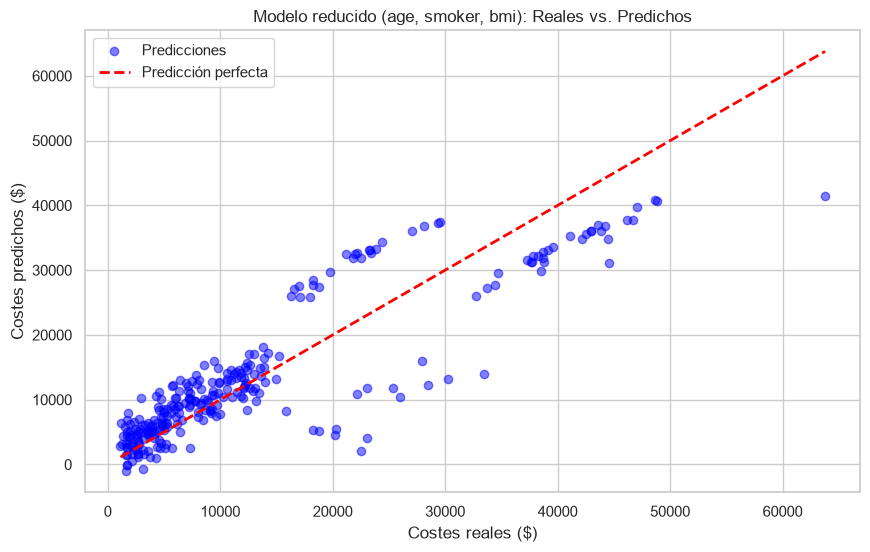

In [44]:
# TODO: completa esta celda
# Las tres columnas ya existen en df_encoded: no hay que volver a codificar nada.
# Manten el mismo random_state y test_size que el modelo completo, o la comparacion de metricas no sera justa.
x_reducido = df_encoded[['age', 'smoker_yes', 'bmi']]
y_simple = df_encoded['charges']

# 2. Divide los datos (mismo test_size y random_state que el modelo completo)
X_train, X_test, y_train, y_test = train_test_split(x_reducido, y_simple, test_size=0.2, random_state=42)

# 3. Crea y entrena el modelo reducido
modelReducido = LinearRegression()
modelReducido.fit(X_train, y_train)
print("¡Modelo entrenado con éxito!")

# 4. Predicciones y evaluación completa
y_pred = modelReducido.predict(X_test)   # <-- faltaba esta línea

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Error Absoluto Medio): ${mae:,.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): ${rmse:,.2f}")
print(f"R-cuadrado (R²): {r2:.2f}")

# 5. Visualización: predicciones vs. valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Predicción perfecta')

plt.title('Modelo reducido (age, smoker, bmi): Reales vs. Predichos')
plt.xlabel('Costes reales ($)')
plt.ylabel('Costes predichos ($)')
plt.legend()
plt.show()

### Mis Reflexiones

**Responde a estas preguntas en una celda de texto (Markdown) al final de tu notebook:**

1.  **Comparación de Modelos:** Compara el $R^2$ y el MAE de este modelo reducido con el del modelo que usaba *todas* las variables. ¿Cuánta precisión (en dólares de error promedio) hemos "sacrificado" a cambio de un modelo más simple?

Hemos perdido aproximadamente unos $100, pero tenemos el mismo indice $R^2$ = 0.78 en las dos tablas. 

2.  **Decisión de Negocio:** Imagina que tienes que presentarle uno de los dos modelos (el completo vs. el reducido) a tu manager. ¿Cuál elegirías y por qué? Justifica tu respuesta pensando en el equilibrio entre rendimiento, simplicidad y explicabilidad.

Eligiria el modelo simple, porque consta con las tablas más relevantes mejorando así su rendimiento. Además de que los resultados entre la comparación de los dos modelos indica que no hay una diferencia notable. Y cabe agregar que gracias a su simplicidad en comparación al modelo completo es más fácil de explicar.  

3.  **Análisis Crítico:** Viendo el gráfico de predicciones vs. realidad de tu modelo reducido, ¿en qué zona parece fallar más? ¿Predice bien los costes muy altos o los muy bajos? ¿Por qué crees que ocurre esto, basándote en las variables que has usado?

Falla en los 2, predice correctamenta los costes bajos pero los costes más altos se alejan más de la linea de predicción. Fallan por que hay más de una posible convinación (viejo + fuma = dispara, etc.) 

---
## Preguntas de recap – Regresión múltiple

1. ¿Cómo interpretas el coeficiente de una variable en una regresión múltiple?

Es el cambio esperado en este caso en (charges) por cada unidad que aumenta esa variable, manteniendo constantes las demás. Por ejempo el coeficiente de age indica cuántos dólares sube el coste por cada año más, con el resto de variables fijas.

2. ¿Por qué puede cambiar el valor de un coeficiente cuando añadimos nuevas variables al modelo?

Porque tiene más datos a los que apoyarse. Además de que, cambia porque las variables están correlacionadas; al añadir una nueva, el modelo reparte el efecto entre ellas, y el coeficiente de la primera pasa a medir solo la parte que la nueva no explica.

3. ¿Qué significa que un modelo esté sobreajustado (overfitting)?  

Es que el modelo se ajusta tan bien a los datos de entrenamiento (incluido el ruido) que generaliza mal.
Buen rendimiento, mal test.

4. ¿Qué ventajas tiene evaluar un modelo con métricas como MAE, RMSE además de R²?

El R² es una medida relativa; te dice qué proporción de la variación de charges explica el modelo, pero no cuánto se equivoca en la práctica. MAE y RMSE completan esa información, mostrando los margenes a nivel numerico

---


---
## Ejercicio 3 — Otro dataset (opcional)

1. Carga un dataset distinto (por ejemplo, `sklearn.datasets.load_diabetes()` o uno que elijas tú).  
2. Ajusta una regresión múltiple con al menos 3 variables predictoras.  
3. Evalúa el modelo usando R² y RMSE.  
4. Interpreta qué variable parece tener más influencia en la predicción.  

Si quieres ir más allá: prueba a estandarizar las variables y compara los coeficientes.
---


In [ ]:
# TODO: completa esta celda
# load_diabetes(as_frame=True) te devuelve .data y .target como objetos de pandas.
# Antes de decidir que variable influye mas, preguntate si estan todas en la misma escala.


### Mis reflexiones sobre el ejercicio 3

*(Escribe aquí tu respuesta)*

- Has ordenado las variables por el tamaño de su coeficiente. ¿En qué condiciones ese ranking significa "influencia" y en cuáles es engañoso? Comprueba si tu dataset cumple esas condiciones.
- Has trabajado con dos datasets con R² muy distintos. ¿Cuál de los dos modelos dirías que es "mejor"? Cuidado con la pregunta.
- Si tuvieras que entregar uno de los modelos de esta sesión a alguien que lo va a usar sin ti delante, ¿qué escribirías en el README para que no lo use mal?
